# Configuration Variables
Define all file paths and parameters in one place for easy template creation

In [2]:
# ====================================================================================
# CONFIGURATION - Edit these variables when creating a new notebook from template
# ====================================================================================

# Experiment identification
DATE = "041225PA"
CONDITION = "experimental"  # "experimental" or "control"

# Video directory and file pattern
VIDEO_DIR = f"/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/{DATE}_{CONDITION}"
VIDEO_PATTERN = f"{VIDEO_DIR}/{DATE}_{CONDITION}_part??.mp4"

# Output files
CONTOURS_OUTPUT_FILE = f"contours_{DATE}_{CONDITION}.tab"
VISUALIZATION_OUTPUT = f"../../results/{DATE}_{CONDITION}.png"
RESULTS_PREFIX = "../../results/April12"

# Tank boundaries (x and y limits)
#**** These are determined by visually inspecting the first frame of the video and will need to be adjusted for different videos ****
X_LINES = [340, 730, 1200, 1630]
Y_LINES = [360, 780]
XLIM = [X_LINES[0], X_LINES[-1]]
YLIM = [Y_LINES[0], Y_LINES[-1]]

# Contour detection parameters
BLACK_THRESHOLD = 110
MIN_AREA = 1.5
MAX_AREA = 1000.0
BRIGHTNESS_THRESHOLD = 50
THREADS = 4

# Visualization parameters
VISUALIZATION_FRAME = 500

print(f"📁 Configuration loaded for: {DATE} {CONDITION}")
print(f"📹 Video pattern: {VIDEO_PATTERN}")
print(f"📊 Output file: {CONTOURS_OUTPUT_FILE}")

📁 Configuration loaded for: 041225PA experimental
📹 Video pattern: /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_part??.mp4
📊 Output file: contours_041225PA_experimental.tab


In [9]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

Figure(640x480)


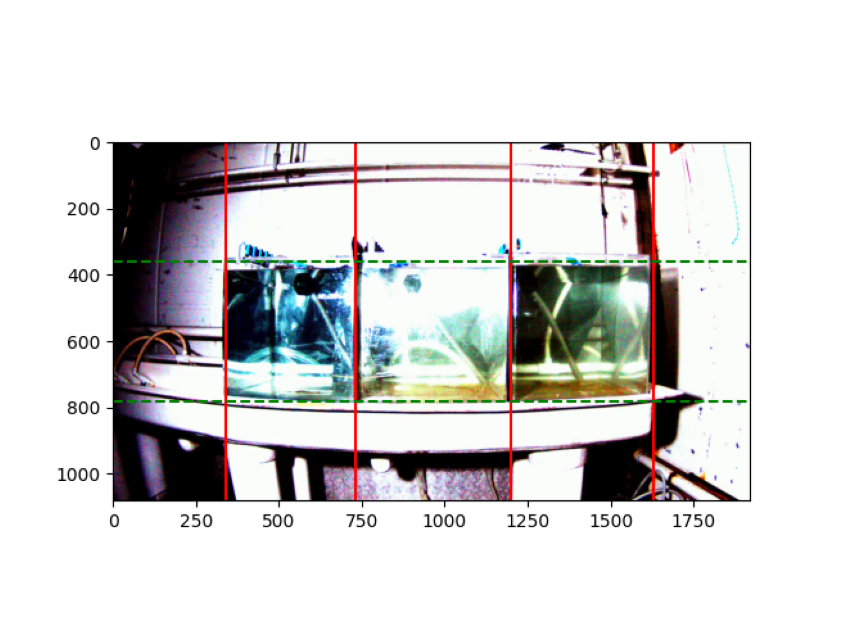

In [10]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os

# Build command using configuration variables
cmd = [
    'python3', '../../scripts/visualize_tanx.py',
    '-v', f'{VIDEO_DIR}/{DATE}_{CONDITION}_part1.mp4',
    '-f', str(VISUALIZATION_FRAME),
    '-t', *map(str, X_LINES),
    '-y', *map(str, Y_LINES),
    '-o', VISUALIZATION_OUTPUT
]

# Run the script
subprocess.run(cmd, check=True)

# Display the image in the notebook
if os.path.exists(VISUALIZATION_OUTPUT):
    img = cv2.imread(VISUALIZATION_OUTPUT)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

In [11]:
# "black frame" is defined by ffmpeg's blackdetect filter with these parameters:
#
#d=0.5: The minimum duration (in seconds) for a black segment to be detected.
#pix_th=0.10: The pixel threshold; a frame is considered "black" if at least 90% of its pixels have a luma (brightness) value below the default threshold (default is 32 out of 255).
#So, a black frame is one where at least 90% of its pixels are very dark (luma < 32), and a black segment is reported if this condition lasts for at least 0.5 seconds.


#Also checks for CFR and converts to CFR if needed before running blackdetect
#Will save with _CFR suffix if conversion is needed.

import subprocess
import cv2
import re
import pandas as pd
import os
import json

# Use part03 video from configuration (adjust part number as needed)
video_path = f"{VIDEO_DIR}/{DATE}_{CONDITION}_part03.mp4"

# Check if video is CFR or VFR using ffprobe
print("Checking frame rate...")
probe_cmd = [
    'ffprobe', '-v', 'error',
    '-select_streams', 'v:0',
    '-show_entries', 'stream=r_frame_rate,avg_frame_rate',
    '-of', 'json',
    video_path
]
probe_result = subprocess.run(probe_cmd, capture_output=True, text=True)
probe_data = json.loads(probe_result.stdout)

r_frame_rate = probe_data['streams'][0]['r_frame_rate']
avg_frame_rate = probe_data['streams'][0]['avg_frame_rate']

# Convert fraction strings to floats
def frac_to_float(frac_str):
    num, denom = map(float, frac_str.split('/'))
    return num / denom

r_fps = frac_to_float(r_frame_rate)
avg_fps = frac_to_float(avg_frame_rate)

print(f"Declared frame rate: {r_fps:.3f} fps")
print(f"Average frame rate: {avg_fps:.3f} fps")

# Check if VFR (difference > 0.1 fps)
is_vfr = abs(r_fps - avg_fps) > 0.1

if is_vfr:
    print(f"⚠️  Video is VFR (variable frame rate). Converting to CFR...")
    cfr_video_path = video_path.replace('.mp4', '_CFR.mp4')
    
    # Check if CFR version already exists
    if os.path.exists(cfr_video_path):
        print(f"CFR version already exists: {cfr_video_path}")
    else:
        # Convert to CFR using the average frame rate
        convert_cmd = [
            'ffmpeg', '-i', video_path,
            '-r', str(avg_fps),
            '-c:v', 'libx264', '-preset', 'medium', '-crf', '18',
            '-c:a', 'copy',
            cfr_video_path
        ]
        print("Converting... this may take a while.")
        subprocess.run(convert_cmd, check=True)
        print(f"✓ Converted to CFR: {cfr_video_path}")
    
    # Use CFR version for analysis
    video_path = cfr_video_path
else:
    print("✓ Video is already CFR (constant frame rate)")

# ffmpeg blackdetect
cmd = (
    f'ffmpeg -hide_banner -nostats -i "{video_path}" '
    '-vf "blackdetect=d=0.5:pix_th=0.10" -an -f null - 2>&1 | grep "black_start" | tail -1'
)
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
line = result.stdout.strip()
print("ffmpeg output:", line)  # Debug print

# Extract blackdetect times
match = re.search(r'black_start:(\d+\.\d+) black_end:(\d+\.\d+) black_duration:(\d+\.\d+)', line)
if match:
    black_start = float(match.group(1))
    black_end = float(match.group(2))
    black_duration = float(match.group(3))
else:
    black_start = black_end = black_duration = None

# OpenCV video info
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
total_length = frame_count / fps if fps else None

def sec_to_mmss(seconds):
    if seconds is None:
        return ""
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"

def sec_to_frame(seconds, fps):
    if seconds is None or not fps:
        return ""
    return int(round(seconds * fps))

table = [
    {"event": "total_length", "frame": frame_count, "time (mm:ss)": sec_to_mmss(total_length)},
    {"event": "blackstart", "frame": sec_to_frame(black_start, fps), "time (mm:ss)": sec_to_mmss(black_start)},
    {"event": "blackend", "frame": sec_to_frame(black_end, fps), "time (mm:ss)": sec_to_mmss(black_end)},
    {"event": "blackduration", "frame": sec_to_frame(black_duration, fps), "time (mm:ss)": sec_to_mmss(black_duration)},
]

darkness = pd.DataFrame(table)
print(darkness)

Checking frame rate...
Declared frame rate: 10.000 fps
Average frame rate: 10.000 fps
✓ Video is already CFR (constant frame rate)
ffmpeg output: [blackdetect @ 0x7f7798003b80] black_start:1542.5 black_end:1802.6 black_duration:260.1
           event  frame time (mm:ss)
0   total_length  18027        30:02
1     blackstart  15425        25:42
2       blackend  18026        30:02
3  blackduration   2601        04:20


In [ ]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

# Run contour finding using configuration variables
results = find_contours_from_videos(
    video_pattern=VIDEO_PATTERN,
    black=BLACK_THRESHOLD,
    minArea=MIN_AREA,
    maxArea=MAX_AREA,
    brightnessThreshold=BRIGHTNESS_THRESHOLD,
    threads=THREADS,
    outfile=CONTOURS_OUTPUT_FILE,
    maxy=None,
    xlim=XLIM,
    ylim=YLIM
)
print(f'Contour results written to {CONTOURS_OUTPUT_FILE}')

Processing videos:   0%|          | 0/25 [00:00<?, ?it/s]

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

...

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/12Apr25/041225PA_experimental/041225PA_experimental_p…

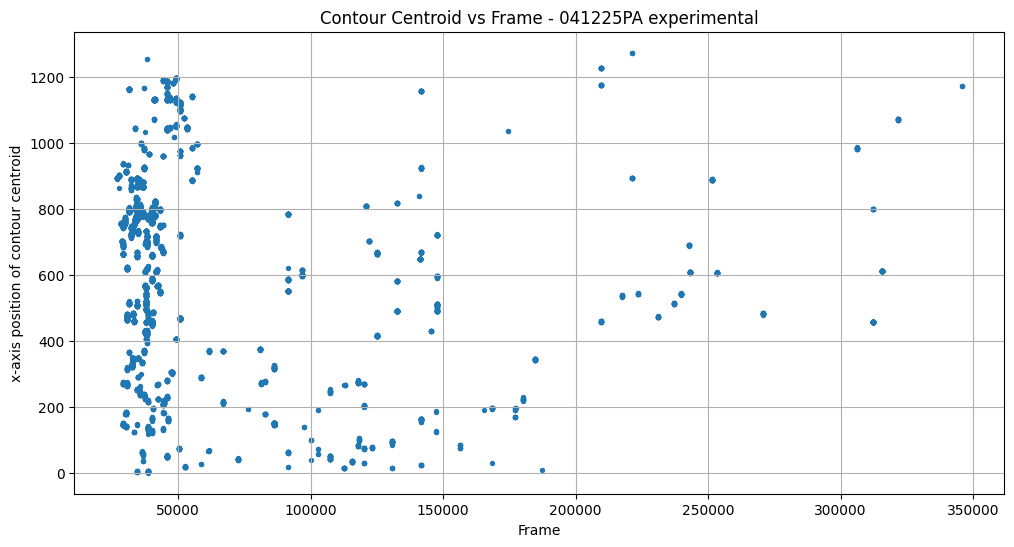

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the tab-separated file using configuration variable
df = pd.read_csv(CONTOURS_OUTPUT_FILE, sep='\t')

# Plot frame vs cX
plt.figure(figsize=(12, 6))
plt.scatter(df['frame'], df['cX'], s=8)
plt.xlabel('Frame')
plt.ylabel('x-axis position of contour centroid')
plt.title(f'Contour Centroid vs Frame - {DATE} {CONDITION}')
plt.grid(True)
#plt.xlim(34000, 35000)
plt.show()